# Exemples de segmentation

In [1]:
import skimage.io as io
from skimage import img_as_ubyte
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import threshold_otsu
from skimage.transform import resize

import matplotlib as mpl
plt.style.use('../bip.mplstyle')
mpl.rcParams['xtick.bottom'] = False
mpl.rcParams['ytick.left'] = False
plt.rcParams['image.cmap'] = 'gray'

## Binarization

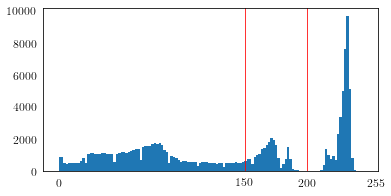

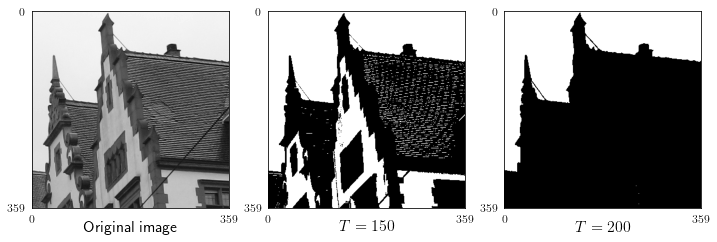

In [2]:
# Load the image
f = io.imread("roof.jpg")
f = rgb2gray(f)

# Thresholds
TT = [150, 200]
N = len(TT)

# Histogram
plt.figure(figsize=(6,3))
plt.hist(f.ravel(), bins=128)
for T in TT:
    plt.axvline(T, color='r', linewidth=.8)
plt.xticks(np.concatenate([[0], TT, [255]]))
plt.savefig("binarization-histogram.svg")
plt.show()

# Show the image
fig, axs = plt.subplots(1,N+1,figsize=(4*(N+1),4))
n = 0
axs[n].imshow(f, cmap="gray")
axs[n].set_xlabel(f"Original image", labelpad=-5)
axs[n].set_xticks([0, f.shape[1]-1])
axs[n].set_yticks([0, f.shape[0]-1])

# Threshold and show
for T in TT:
    g = (f>T) * 255
    
    n += 1
    axs[n].imshow(g, cmap="gray")
    axs[n].set_xlabel(f"$T = {T}$", labelpad=-5)
    axs[n].set_xticks([0, f.shape[1]-1])
    axs[n].set_yticks([0, f.shape[0]-1])

# Save
plt.savefig("binarization.svg")
plt.show()

# Otsu

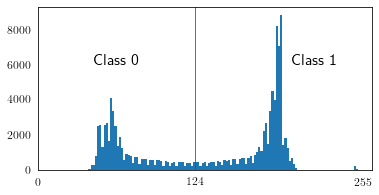

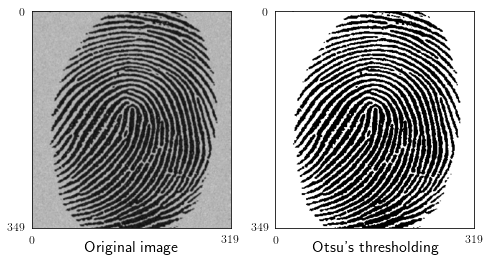

In [3]:
# Load the image
f = io.imread("originals/finger-original.png")
f = rgb2gray(f)
f = f[30:-3,:]

T = threshold_otsu(f)

# Histogram
plt.figure(figsize=(6,3))
plt.hist(f.ravel(), bins=128)
plt.axvline(T, color='r', linewidth=.8)
plt.text(62,6000, "Class 0", ha="center")
plt.text(200,6000, "Class 1", ha="left")
plt.xticks(np.concatenate([[0], [T], [255]]))
plt.savefig("otsu-histogram.svg")
plt.show()

# Show the image
fig, axs = plt.subplots(1,2,figsize=(8,4))
axs[0].imshow(f, cmap="gray")
axs[0].set_xlabel(f"Original image", labelpad=-5)
axs[0].set_xticks([0, f.shape[1]-1])
axs[0].set_yticks([0, f.shape[0]-1])

# Threshold and show
g = (f>T) * 255
axs[1].imshow(g, cmap="gray")
axs[1].set_xlabel("Otsu's thresholding", labelpad=-5)
axs[1].set_xticks([0, f.shape[1]-1])
axs[1].set_yticks([0, f.shape[0]-1])

# Save
plt.savefig("otsu.svg")
plt.show()

## Multiple Thresholds

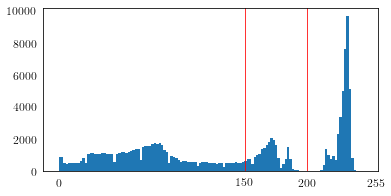

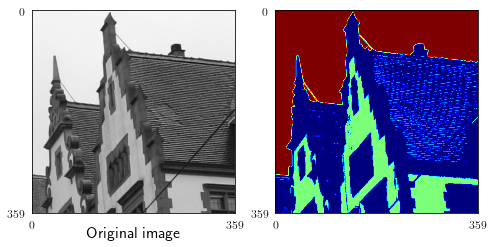

In [4]:
# Load the image
f = io.imread("roof.jpg")
f = rgb2gray(f)

# Thresholds
TT = [150, 200]
N = len(TT)

# Histogram
plt.figure(figsize=(6,3))
plt.hist(f.ravel(), bins=128)
for T in TT:
    plt.axvline(T, color='r', linewidth=.8)
plt.xticks(np.concatenate([[0], TT, [255]]))
plt.show()

# Show the image
fig, axs = plt.subplots(1,2,figsize=(8,4))
n = 0
axs[n].imshow(f, cmap="gray")
axs[n].set_xlabel(f"Original image", labelpad=-5)
axs[n].set_xticks([0, f.shape[1]-1])
axs[n].set_yticks([0, f.shape[0]-1])

# Threshold and show
g = np.zeros(f.shape)
for T in TT:
    g += (f>T)
g = g/N*255

axs[1].imshow(g, cmap="jet")
axs[1].set_xticks([0, f.shape[1]-1])
axs[1].set_yticks([0, f.shape[0]-1])

# Save
plt.savefig("multiple-thresholds.svg")
plt.show()